In [ ]:
%matplotlib ipympl
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.collections import PatchCollection, LineCollection
import os

In [2]:
from raytracer_2d import (
    get_rect_subdivs,
    get_rects_center_2d,
    get_rects_edges_2d,
    get_rects_verts_2d,
    get_fov_pixel_centers_2d,
    get_rays_2d,
    get_fov_verts_2d,
    get_verts_sorted_2d,
    # get_convex_hull_2d,
    get_cuts_ray_on_edges_2d,
)

from raytracer_2d import plot_rects, plot_scanner_2d

In [38]:
def get_verts_sorted_by_angel_2d(
    vertices: torch.Tensor, ref_point: torch.Tensor
) -> torch.Tensor:
    # sort the vertices by angle to point ref_point
    rads = torch.atan2(
        vertices[:, 1] - ref_point[1], vertices[:, 0] - ref_point[0]
    )
    rads = (rads + 2 * torch.pi) % (2 * torch.pi)
    order = torch.argsort(rads)
    return vertices[order], rads[order]


def get_three_p_cross(points):
    return (
        points[1, 0] * (points[2, 1] - points[0, 1])
        + points[2, 0] * (points[0, 1] - points[1, 1])
        + points[0, 0] * (points[1, 1] - points[2, 1])
    )


def get_verts_sorted_by_xy_2d(verts: torch.Tensor) -> torch.Tensor:
    # sort the vertices by x
    verts = verts[torch.argsort(verts[:, 0])]
    # sort the vertices again by y if x is the same
    return verts[torch.argsort(verts[:, 1])]


def get_convex_hull_2d(points: torch.Tensor) -> torch.Tensor:
    # sort the points by x and y
    points = get_verts_sorted_by_xy_2d(points)
    # sort the points by angle reference to the first point
    points = get_verts_sorted_by_angel_2d(points, points[0])[0]
    # get the convex hull
    convex_hull = points[:2]
    for i in range(2, points.shape[0]):
        convex_hull = torch.vstack((convex_hull, points[i]))
        if (
            convex_hull.shape[0] > 1
            and get_three_p_cross(convex_hull[-3:]) <= 0
        ):
            convex_hull = torch.vstack([convex_hull[:-2], convex_hull[-1]])
    return convex_hull


def if_rects_in_hull_2d(rects, hull):
    points = get_rects_verts_2d(rects)
    n_rects = rects.shape[0]
    n_hull = hull.shape[0]

    # hull = get_verts_sorted_2d(hull)

    p0_tensor = hull.unsqueeze(0).unsqueeze(0).expand(n_rects, 4, n_hull, 2)
    p1_tensor = (
        torch.vstack([hull[1:], hull[0]])
        .unsqueeze(0)
        .unsqueeze(0)
        .expand(n_rects, 4, n_hull, 2)
    )
    p2_tensor = points.unsqueeze(2).expand(-1, -1, n_hull, 2)
    v1 = p1_tensor - p0_tensor
    v2 = p2_tensor - p0_tensor
    cross = torch.sign(
        v2[:, :, :, 0] * v1[:, :, :, 1] - v2[:, :, :, 1] * v1[:, :, :, 0]
    ).view(n_rects, 4, n_hull)
    return torch.logical_or(
        (cross >= 0).all(dim=2), (cross <= 0).all(dim=2)
    ).all(dim=1)


def if_rects_intersect_hull_2d(rects, hull, sub_center):
    # get the edges of the rectangles
    edges = get_rects_edges_2d(rects)
    verts, rads = get_verts_sorted_by_angel_2d(hull, sub_center)
    ends = verts[[1, -1]]
    print(rads)
    rays = get_rays_2d(ends, sub_center.view(1, 2))
    _, index = get_cuts_ray_on_edges_2d(rays, edges)
    return torch.unique(index[:, 1]), rays


def get_furthest_corners(verts, n_corners: int = 4) -> torch.Tensor:
    centroid = torch.mean(verts, dim=0)
    dist_to_centroid = torch.norm(verts - centroid, dim=1)
    order = torch.argsort(dist_to_centroid)
    return verts[order[-n_corners:]].view(n_corners, 2)

tensor([0.0000, 2.9974, 3.0642, 3.5117, 3.7694])


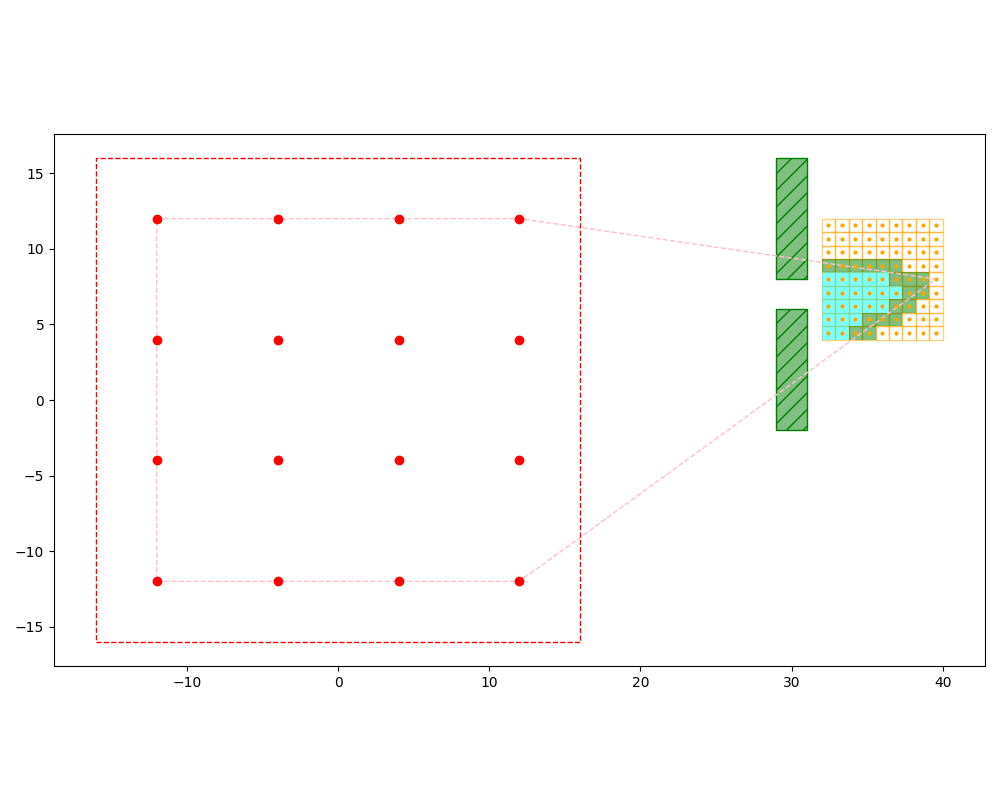

In [45]:
# define the subdivisions of the crystal
rect = torch.tensor(
    [[32, 4], [8, 0], [0, 8]],
    dtype=torch.float32,
)
xtal_nsubs = torch.tensor([9, 9])

rect_subs = get_rect_subdivs(rect, xtal_nsubs)
plate_rects = torch.tensor(
    [
        [[29, 8], [2, 0], [0, 8]],
        [[29, -2], [2, 0], [0, 8]],
    ],
    dtype=torch.float32,
)
# define the field of view (FOV)
fov_npx = torch.tensor([4, 4])
fov_mmppx = torch.tensor([8, 8])
fov_dims = fov_npx * fov_mmppx

# get the points a and b for the rays
pa_tensor = get_fov_pixel_centers_2d(fov_npx, fov_mmppx)
pb_tensor = get_rects_center_2d(rect_subs)
rays = get_rays_2d(pa_tensor.view(-1, 2), pb_tensor.view(-1, 2))

fov_verts = get_fov_verts_2d(fov_dims)
pixel_corners = get_furthest_corners(pa_tensor.view(-1, 2), 4)


i_list = [76]
for i in i_list:
    candidates = torch.vstack(
        (plate_rects, rect_subs[~torch.arange(rect_subs.shape[0]).eq(i)])
    )
    candidates_verts = get_rects_verts_2d(candidates)
    hull = get_convex_hull_2d(torch.vstack((pb_tensor[i], pixel_corners)))
    valid_indices, test_rays = if_rects_intersect_hull_2d(
        candidates, hull, pb_tensor[i]
    )
    insid_indices = if_rects_in_hull_2d(candidates, hull)
    try:
        plt.close()
    except Exception as e:
        pass
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111)
    ax.set_aspect("equal")
    pstyles = [
        {"fc": "none", "ec": "green", "hatch": "//", "label": "Plate"},
        {"fc": "none", "ec": "orange", "alpha": 0.5, "label": "Subdivisions"},
    ]
    plot_scanner_2d(ax, [plate_rects, rect_subs], rays, pstyles)
    plot_rects(candidates[valid_indices], ax, fc="green", ec="none", alpha=0.5)
    plot_rects(candidates[insid_indices], ax, fc="cyan", ec="none", alpha=0.5)
    # ax.plot(result[:, 0], result[:, 1], "o", ms=4, c="purple")
    ax.add_patch(
        Polygon(
            hull,
            closed=True,
            fill=None,
            edgecolor="pink",
            linestyle="--",
            linewidth=1,
        )
    )
    ax.add_patch(
        Polygon(
            fov_verts,
            closed=True,
            fill=None,
            edgecolor="r",
            linestyle="--",
            linewidth=1,
        )
    )
    # print("shape of test_rays", test_rays.shape)
    # line_segments = LineCollection(
    #     test_rays.view(-1, 2, 2).tolist(),
    #     colors="purple",
    #     linewidth=1,
    #     linestyle="--",
    # )
    # ax.add_collection(line_segments) # type: ignore
    # plot_rays(ax, rays_cutted, color="purple", linewidth=1)
    # xlims = ax.get_xlim()
    # ylims = ax.get_ylim()
    # ax.set_xlim(ax.get_xlim()[0] - 10, ax.get_xlim()[1] + 10)
    # ax.set_ylim(ax.get_ylim()[0] - 10, ax.get_ylim()[1] + 10)

    ax.plot(
        pa_tensor.view(-1, 2)[:, 0], pa_tensor.view(-1, 2)[:, 1], "o", c="r"
    )
    plt.tight_layout()
    # output_dir = (
    #     f"outputs/images/subdivs_{xtal_nsubs[0].item()}x{xtal_nsubs[1].item()}"
    # )
    # os.makedirs(output_dir, exist_ok=True)
    # fig.savefig(f"{output_dir}/fixfix/{i:03d}.png")

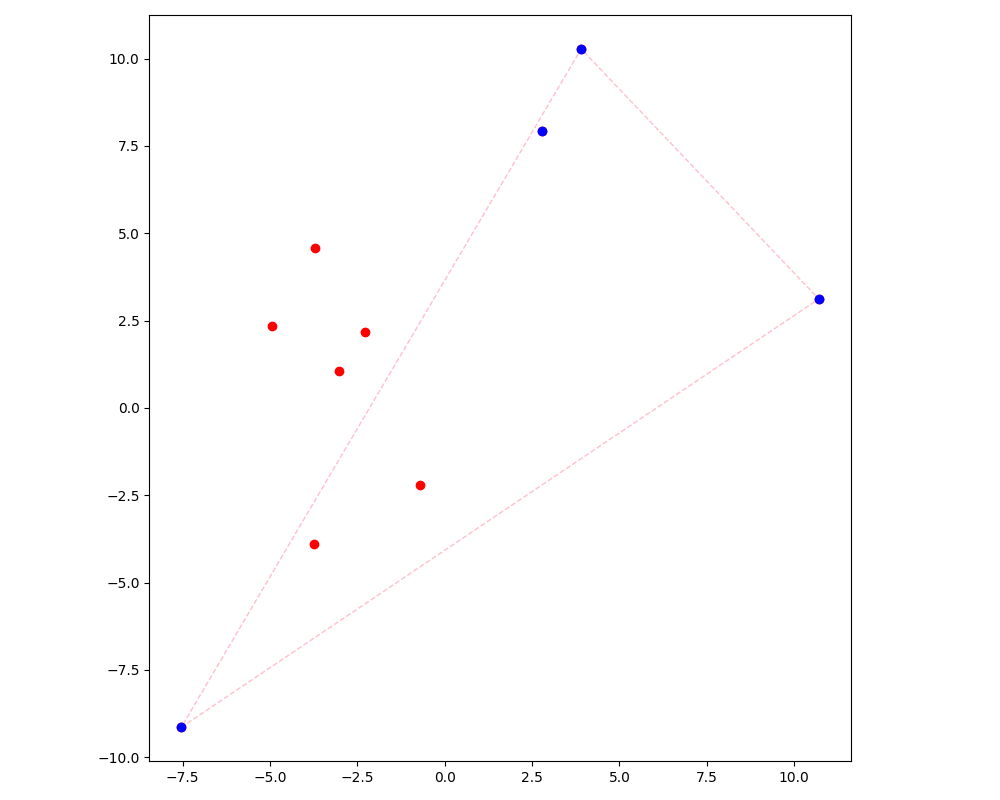

In [43]:
def get_furthest_corners(verts, n_corners: int = 4) -> torch.Tensor:
    centroid = torch.mean(verts, dim=0)
    dist_to_centroid = torch.norm(verts - centroid, dim=1)
    order = torch.argsort(dist_to_centroid)
    return verts[order[-n_corners:]].view(n_corners, 2)


try:
    plt.close()
except Exception as e:
    pass

# test_verts = torch.tensor([[0, 0], [3, 5], [1, 1], [0, 1]], dtype=torch.float32)
test_verts = torch.randn(10, 2) * 5
test_corners = get_furthest_corners(test_verts)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
ax.set_aspect("equal")
ax.plot(test_verts[:, 0], test_verts[:, 1], "o", c="r")
ax.plot(test_corners[:,0], test_corners[:,1], "o", c="b")
hull = get_convex_hull_2d(test_corners)
ax.add_patch(
    Polygon(
        hull,
        closed=True,
        fill=None,
        edgecolor="pink",
        linestyle="--",
        linewidth=1,
    )
)
plt.tight_layout()